In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import blackjax
import jax
import jax.numpy as jnp
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

from density import rdmc_approx_likelihood
from confrdm.simulators.rdmc import simulate_rdmc_two_accumulators

INFO:2025-12-05 14:29:07,811:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [ ]:
param_names = ["v_c_intercept", "v_c_slope", "amp", "tau", "s_true", "b", "t0"]

prior_draws = np.array([0.05, 0.3, 10, 60, 4.5, 70, 300])
data = simulate_rdmc_two_accumulators(
    prior_draws[0],
    prior_draws[1],
    prior_draws[2],
    prior_draws[3],
    prior_draws[4],
    4.0,
    prior_draws[5],
    prior_draws[6],
    2,
    250,
    5000,
)
rt, choice = data["x"][:, 0], data["x"][:, 1]
rt *= 1000

0.768


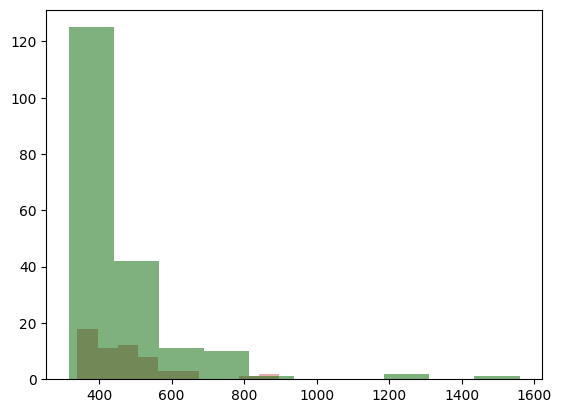

In [4]:
fig, ax = plt.subplots()

ax.hist(rt[choice==0], alpha = 0.5, color="indianred")
ax.hist(rt[choice==1], alpha = 0.5, color="darkgreen")

print(np.mean(choice))

plt.show()

In [5]:
%%timeit

jnp.sum(rdmc_approx_likelihood(
    rt,
    choice,
    0.05, 0.5, 20.0, 60.0, 4.5, 4.0, 75.0, 300.0, 2.0,
    1500.0,
    10.0,
))

7.98 ms ± 827 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [6]:
from mcmc import warmup, inference_loop_multiple_chains

@jax.jit
def ll_fun(x):
    x = jnp.exp(x)
    v_intercept, v_slope, A, tau, s_true, b, t0 = x
    s_false = 4.0
    a_shape = 2.0

    return jnp.sum(rdmc_approx_likelihood(
        rt,
        choice,
        v_intercept,
        v_slope,
        A,
        tau,
        s_true,
        s_false,
        b,
        t0,
        a_shape,
        1500.0,
        10.0,
    ))

In [7]:
ll_fun(jnp.log(jnp.array([0.05, 0.5, 10.0, 30.0, 4.0, 70.0, 300.0])))

Array(-1696.00803205, dtype=float64)

In [ ]:
init_position = jnp.array([0.05, 0.5, 10.0, 30.0, 4.0, 70.0, 300.0])

rng_key = jax.random.key(2025)

warmup_key, sampling_key = jax.random.split(rng_key, 2)

_, last_state, warmup_parameters = warmup(blackjax.hmc, ll_fun, jnp.log(init_position), 100, warmup_key, num_integration_steps=100, progress_bar=True)

last_state.position.block_until_ready()
warmup_parameters

Running window adaptation


{'step_size': Array(0.0003683, dtype=float64, weak_type=True),
 'inverse_mass_matrix': Array([1.65369858e-04, 7.91179940e-04, 3.96415945e-04, 8.08529959e-04,
        7.08441884e-04, 9.97666175e-05, 4.18853465e-04], dtype=float64),
 'num_integration_steps': 100}

In [64]:
jnp.exp(last_state.position)

Array([4.76514548e-02, 5.32219600e-01, 8.18338524e+00, 2.89854631e+01,
       4.21978123e+00, 6.91468704e+01, 2.92632699e+02], dtype=float64)

In [ ]:
kernel = blackjax.hmc(ll_fun, **warmup_parameters).step

num_chains = 1
last_states = jax.vmap(lambda x: last_state)(jnp.arange(num_chains))

final_state = inference_loop_multiple_chains(sampling_key, kernel, last_states, 100, num_chains)
final_state.position.block_until_ready();


Array([[[-3.04383981, -0.6312968 ,  2.10153398,  3.36732695,
          1.44169125,  4.23606792,  5.67895481]],

       [[-3.04460085, -0.63011587,  2.10197559,  3.36613851,
          1.44188614,  4.23590211,  5.67894583]],

       [[-3.04426532, -0.63017345,  2.10216136,  3.36579045,
          1.44138276,  4.23625921,  5.6797059 ]],

       [[-3.04422551, -0.62959532,  2.10250673,  3.36685391,
          1.4413087 ,  4.23584484,  5.67896902]],

       [[-3.0443765 , -0.62959058,  2.10293288,  3.3669431 ,
          1.44055604,  4.23590183,  5.67732863]],

       [[-3.04507291, -0.63068904,  2.10237649,  3.36562339,
          1.44102397,  4.23590863,  5.67694455]],

       [[-3.04507291, -0.63068904,  2.10237649,  3.36562339,
          1.44102397,  4.23590863,  5.67694455]],

       [[-3.04556158, -0.62943832,  2.10152607,  3.36730198,
          1.44221147,  4.23589436,  5.67637756]],

       [[-3.0448868 , -0.62785928,  2.10052169,  3.36807013,
          1.44211502,  4.23571875,  5.67642

In [66]:
blackjax.diagnostics.potential_scale_reduction(final_state.position)

Array([nan, nan, nan, nan, nan, nan, nan], dtype=float64)

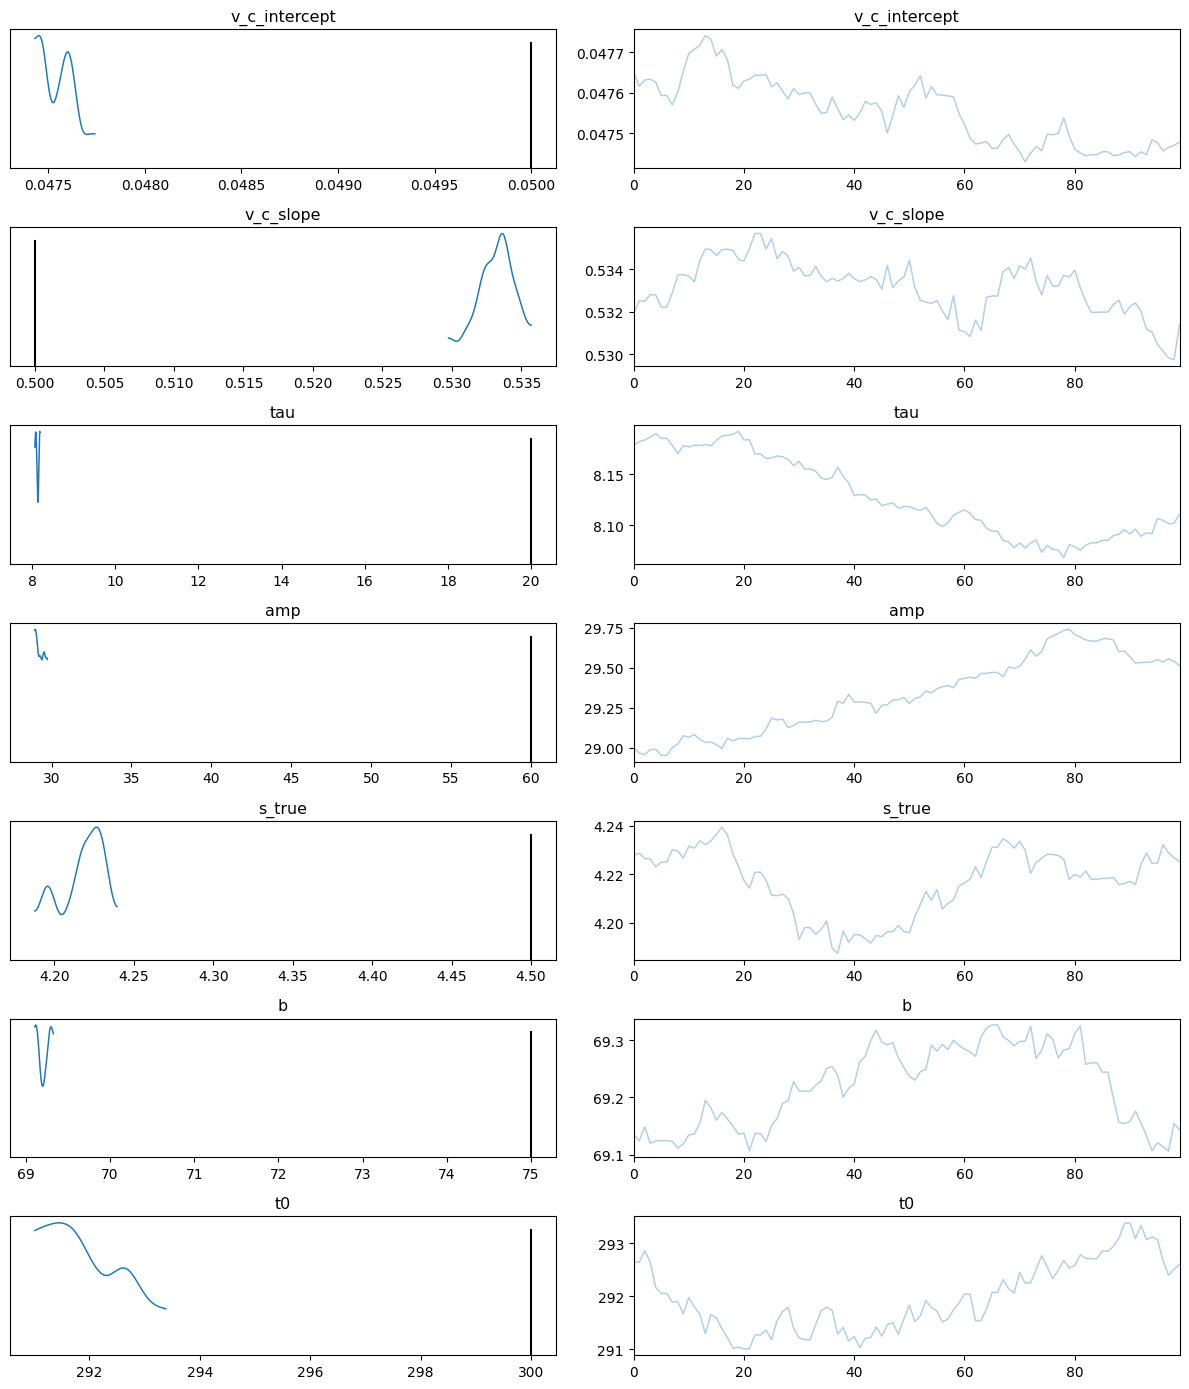

In [ ]:
reference_values = {
    key: val for key, val in zip(param_names, prior_draws)
}

idata = az.from_dict(
    posterior={k: v
               for k, v in zip(param_names, np.moveaxis(np.exp(final_state.position), (0, 1, 2), (2, 1, 0)))})
ax = az.plot_trace(idata)

for i, p in enumerate(prior_draws):
    ax[i, 0].axvline(p, 0, 0.9, color="k")

plt.tight_layout()

In [33]:
def prior_log_prob(x):
    # x shape: (..., 7)
    x = jnp.exp(x)
    v_c_intercept_lp = jax.scipy.stats.norm.logpdf(x[..., 0], loc=0.05, scale=0.05)
    v_c_slope_lp     = jax.scipy.stats.norm.logpdf(x[..., 1], loc=0.5, scale=0.1)
    tau_lp           = jax.scipy.stats.gamma.logpdf(x[..., 2], a=8, scale=10)
    amp_lp           = jax.scipy.stats.gamma.logpdf(x[..., 3], a=10, scale=2)
    s_true_lp        = jax.scipy.stats.gamma.logpdf(x[..., 4], a=80, scale=0.05)
    b_lp             = jax.scipy.stats.gamma.logpdf(x[..., 5], a=100, scale=0.7)
    t0_lp            = jax.scipy.stats.norm.logpdf(x[..., 6], loc=300, scale=200)
    return (
        v_c_intercept_lp
        + v_c_slope_lp
        + tau_lp
        + amp_lp
        + s_true_lp
        + b_lp
        + t0_lp
    )

In [34]:
from priors import truncated_normal_rvs

def sample_prior_particles(n_samples, seed=2025):
    rng = np.random.default_rng(seed)
    v_c_intercept = truncated_normal_rvs(loc=0.05, scale=0.05, size=n_samples, random_state=rng)
    v_c_slope     = truncated_normal_rvs(loc=0.5, scale=0.1, size=n_samples, random_state=rng)
    tau           = rng.gamma(shape=8, scale=10, size=n_samples)
    amp           = rng.gamma(shape=10, scale=2, size=n_samples)
    s_true        = rng.gamma(shape=80, scale=0.05, size=n_samples)
    b             = rng.gamma(shape=100, scale=0.7, size=n_samples)
    t0            = truncated_normal_rvs(loc=300, scale=50, size=n_samples, random_state=rng)
    # Stack in the order of param_names
    return np.log(np.stack([v_c_intercept, v_c_slope, tau, amp, s_true, b, t0], axis=-1))

In [ ]:
import blackjax.smc.resampling as resampling
from blackjax.smc import extend_params
from smc import smc_inference_loop

rng_key = jax.random.key(2025)

n_samples = 1000

inv_mass_matrix = jnp.eye(7) * 1e-4

hmc_parameters = dict(
    step_size=1e-2, inverse_mass_matrix=inv_mass_matrix, num_integration_steps=100
)

kernel_fun = blackjax.hmc

tempered = blackjax.adaptive_tempered_smc(
    prior_log_prob,
    ll_fun,
    kernel_fun.build_kernel(),
    kernel_fun.init,
    extend_params(hmc_parameters),
    resampling.systematic,
    0.5,
    num_mcmc_steps=1,
)

rng_key, init_key, sample_key = jax.random.split(rng_key, 3)
initial_smc_state = sample_prior_particles(n_samples, seed=2025)
initial_smc_state = tempered.init(initial_smc_state)

num_chains = 4

sample_keys = jax.random.split(sample_key, num_chains)

# initial_smc_states = tempered.init([sample_prior_particles(n_samples, i) for i in np.arange(num_chains)])

n_iter, smc_samples, smc_history = jax.vmap(smc_inference_loop, in_axes=(0, None, None))(sample_keys, tempered.step, initial_smc_state)
print("Number of steps in the adaptive algorithm: ", n_iter)

In [41]:
smc_history = jax.tree.map(lambda h: h[:, : n_iter[0] + 1], smc_history)

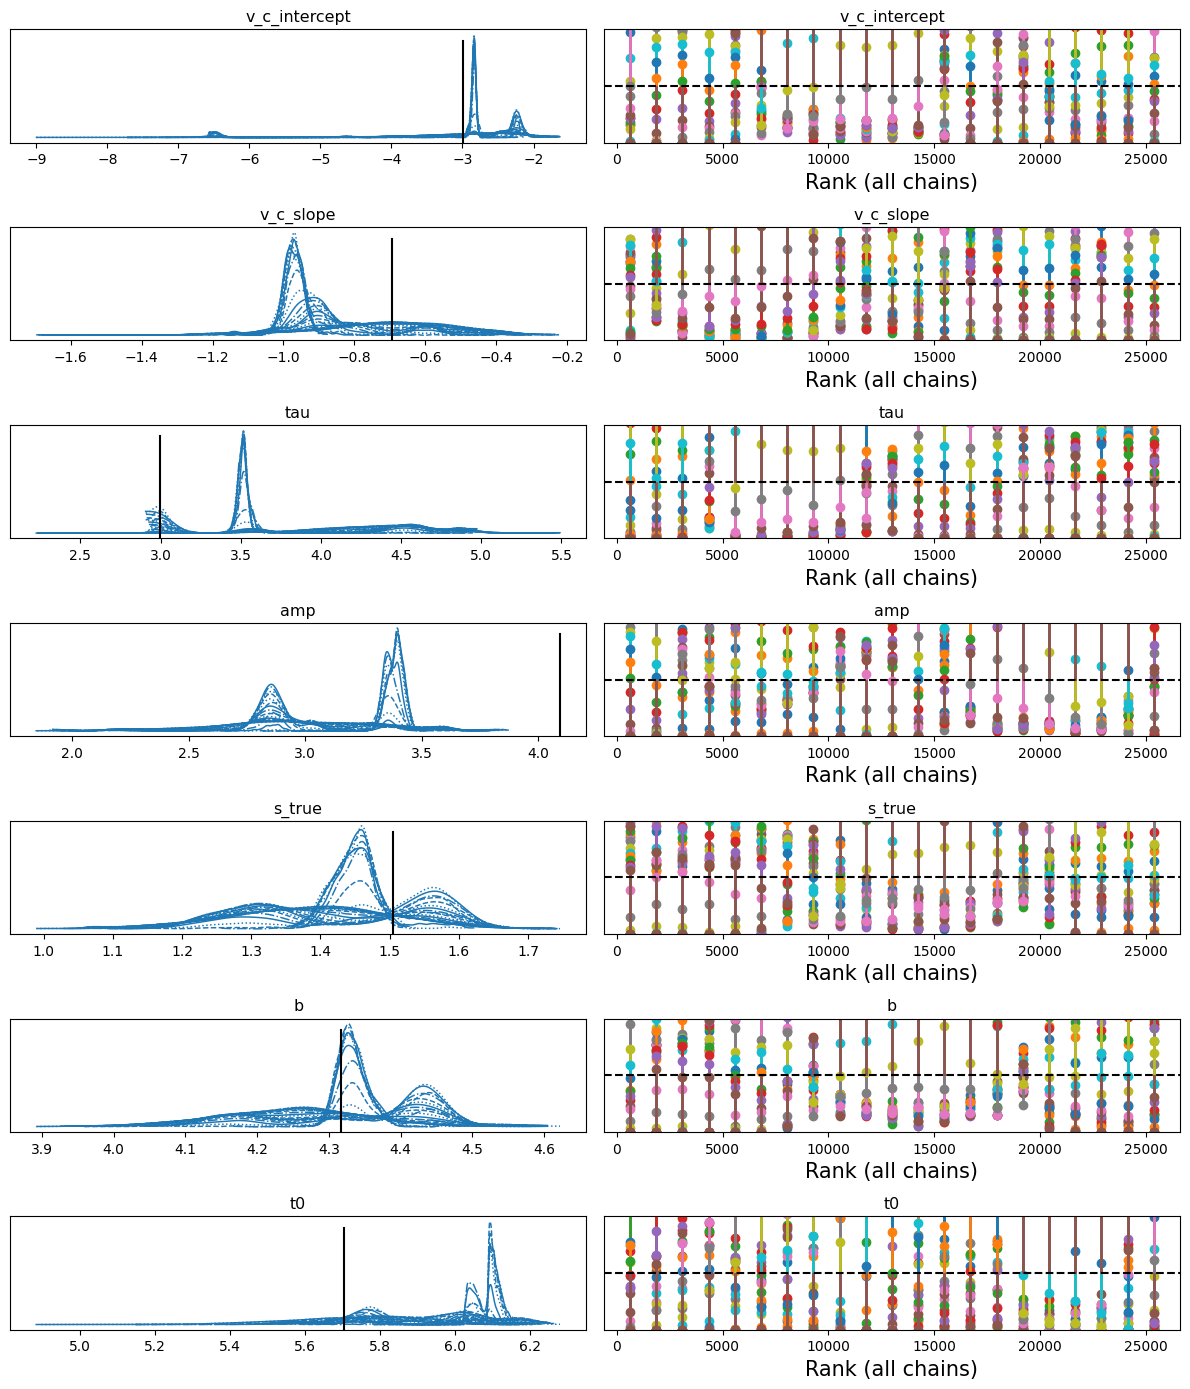

In [ ]:
param_names = ["v_c_intercept", "v_c_slope", "tau", "amp", "s_true", "b", "t0"]

idata = az.from_dict(
    posterior={k: v
               for k, v in zip(param_names, np.moveaxis(smc_history.particles[0], (2, 0, 1), (0, 1, 2)))},)
ax = az.plot_trace(idata, compact=True, kind="rank_vlines")

for i, p in enumerate(np.log(prior_draws)):
    ax[i, 0].axvline(p, 0, 0.9, color="k")

plt.tight_layout()

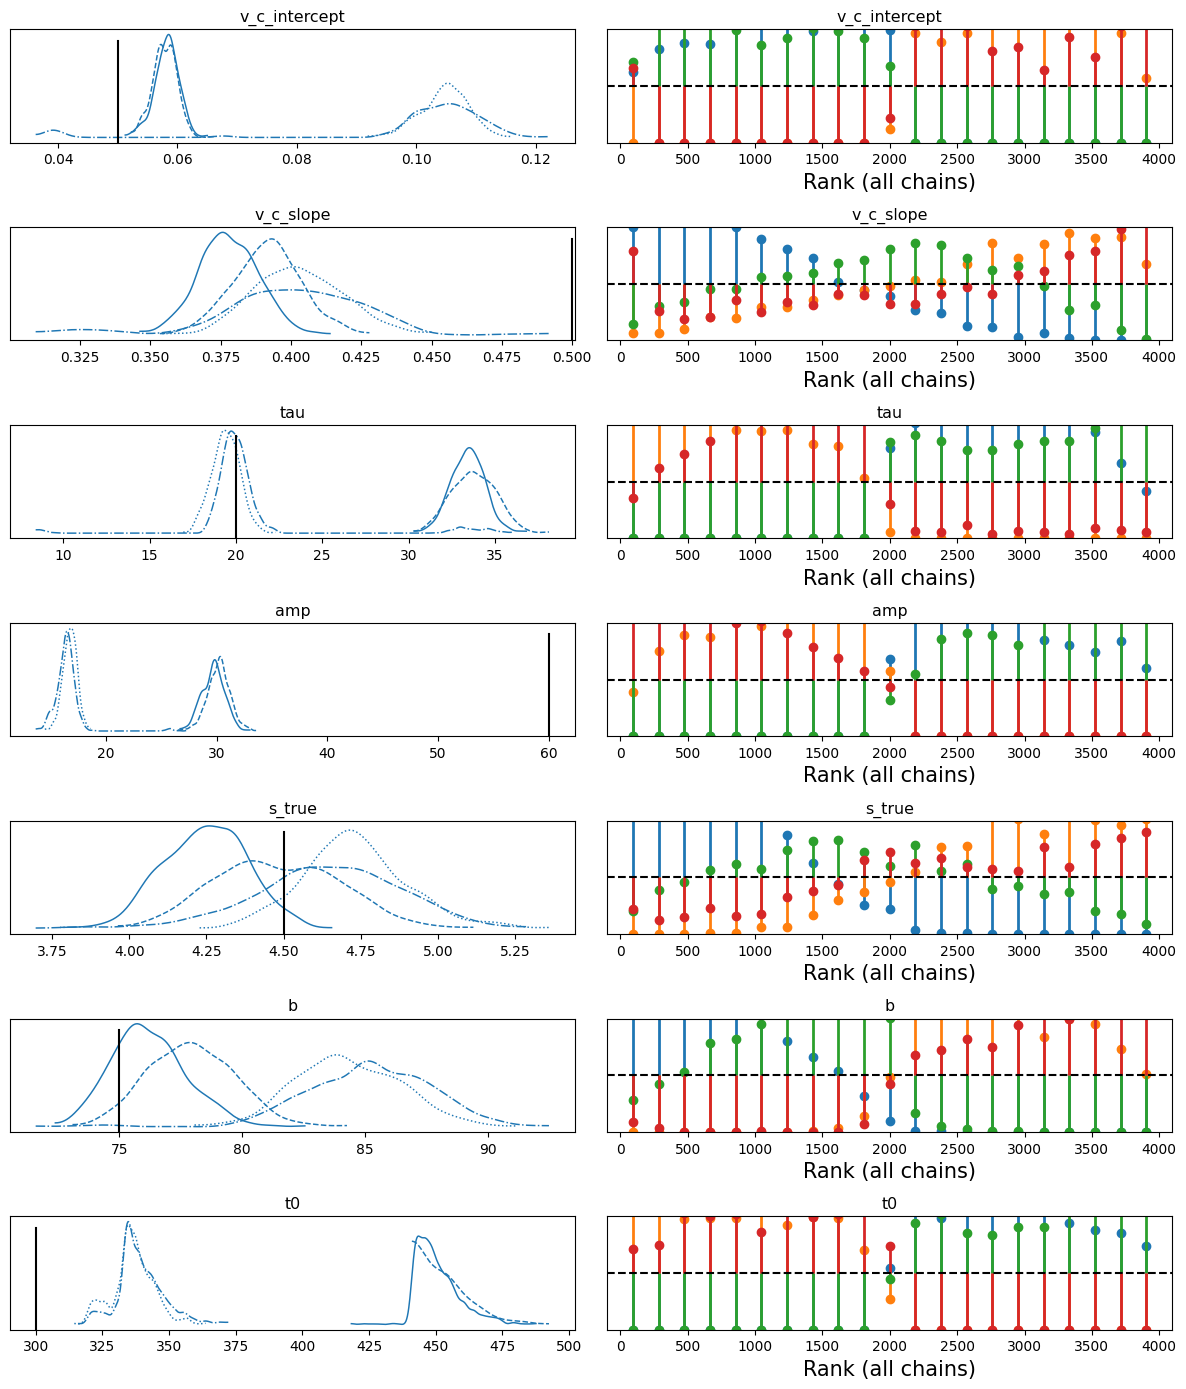

In [ ]:
import arviz as az
import matplotlib.pyplot as plt

idata = az.from_dict(
    posterior={k: v
               for k, v in zip(param_names, np.exp(np.moveaxis(smc_samples.particles, (2, 0, 1), (0, 1, 2))))},)
ax = az.plot_trace(idata, compact=True, kind="rank_vlines")

for i, p in enumerate(prior_draws):
    ax[i, 0].axvline(p, 0, 0.9, color="k")

plt.tight_layout()